#<h1><center>Lab 3 - A3</center></h1>

## Algoritmi evolutivi

Algoritmul evolutiv pentru problema rucsacului va fi implementat pe baza unei reprezentări binare,
repararea indivizilor care reprezintă soluţii nevalide (pentru a respecta capacitatea rucsacului) şi o
funcţie de fitness ce calculeaza valoarea totală pusă în rucsac (ce trebuie maximizată).
Algoritmul evolutiv pentru problema TSP va fi implementat pe baza unei reprezentări prin permutări,
folosirea unor operatori de încrucișare și mutaţie care generează soluţii valide și o funcţie de fitness
ce calculează distanţa totală parcursă (ce trebuie minimizată).
Componentele algoritmului sunt:
* Generare populaţie iniţială aleator (populaţie P).
* Selecţie părinţi.
* Generare descendenţi: încrucişare şi mutaţie (populaţie O).
* Selecţie supravieţuitori: cei mai buni size(P) din P+O.
* Parametri algoritm: mărimea populaţiei, numărul de generaţii, probabilitatea de încrucişare,
probabilitatea de mutaţie.


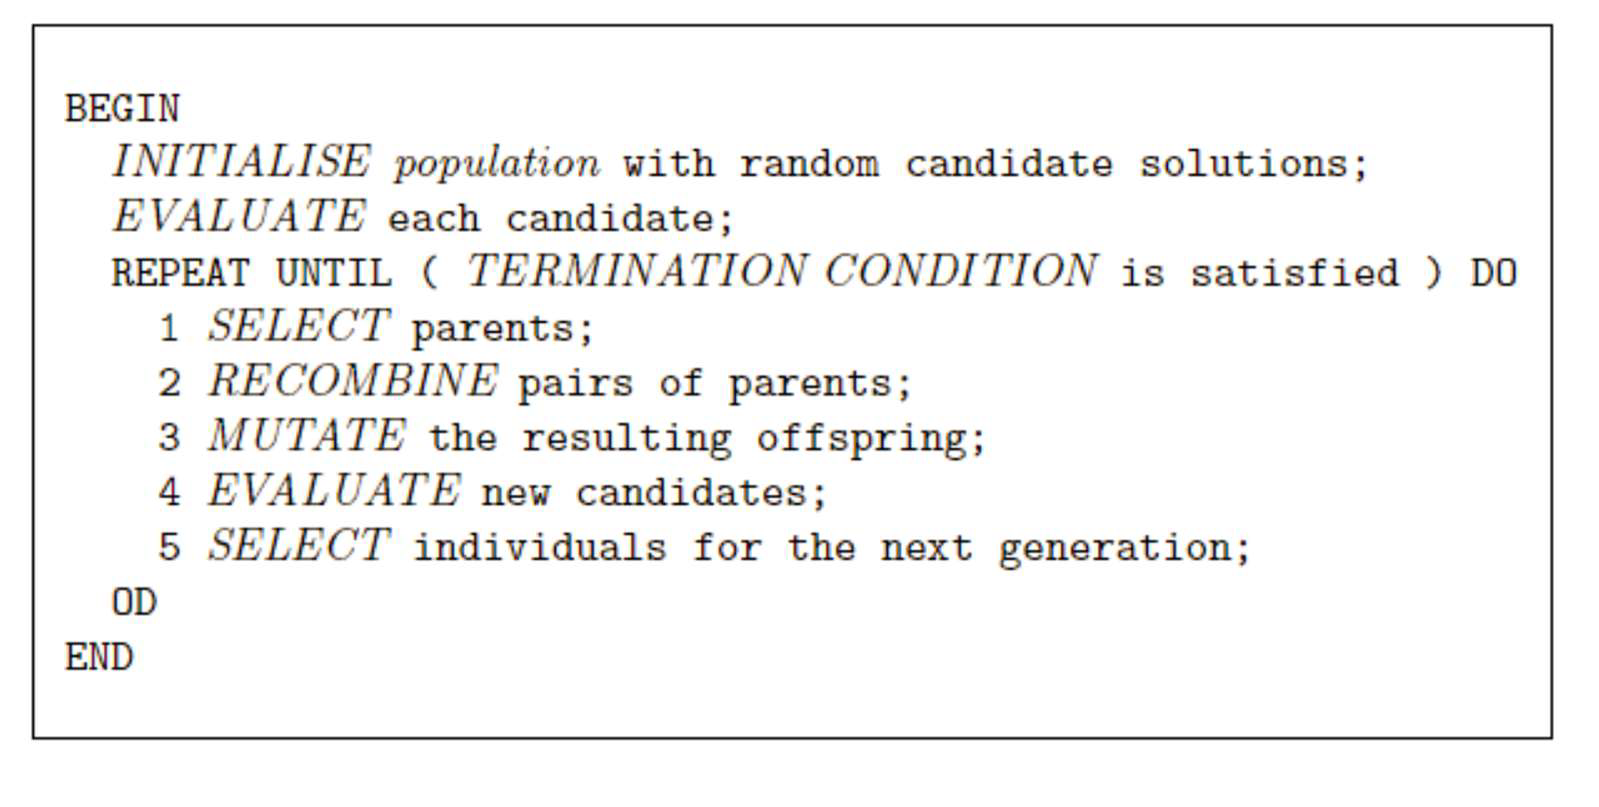

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time

##	Lucru în timpul laboratorului

1. Completarea de cod în fișierul Jupyter Notebook (A2.ipynb) unde este notat cu TODO:
 1. Selecție părinți
 1. Selecție generație următoare
 1. Implementare mutație pentru soluție cu codificare binară
 1. Implementare încrucișare pentru soluție cu codificare binară
 1. Completare algoritm evolutiv pentru codificare binară
 1. Implementare mutație pentru soluție cu codificare prin permutări
 1. Implementare încrucișare pentru soluție cu codificare prin permutări
 1. Completare algoritm evolutive pentru codificare prin permutări
 1. Implementare funcție pentru codificare reală

**Total Punctaj A3-Lab = 60p**

**Deadline Lab 3**

### Funcții problema rucsacului

#### Încărcare de date

In [ ]:
# definire încărcare date
def load_data_rucsac(file_name: str) -> "tuple[list[tuple[int, int]], int]":
  """
  Citeste datele din fisierul file_name
  """
  weights_and_values = []
  with open(file_name) as f:
    nr_obj = int(f.readline())
    for i in range(nr_obj):
      line = f.readline()
      line = line.split(" ")
      line = [x for x in line if x != ""]
      weights_and_values.append(tuple(int(x) for x in line[1:]))
    max_capacity = int(f.readline())
  return weights_and_values, max_capacity
#load_data_rucsac("/content/rucsac-200.txt") # rucsac-20.txt and rucsac-200.txt

#### Formarea unei soluții, vecinătate și fitness

In [ ]:
# definire funcții de fitness/evaluare și generare

def is_valid_rucsac(objects: list, sol: list, max_capacity: int):
  """
  Verifica validitatea unei solutii
  """
  weight = 0
  i = 0
  while i < len(sol) and weight <= max_capacity:
    weight += objects[i][1] * sol[i]
    i += 1
  return weight <= max_capacity

def random_neighbor_rucsac(sol: list):
  """
  Generează un vecin aleatoriu pentru o soluție
  """
  x = sol[:]
  index = np.random.randint(len(sol))
  x[index] = 1 - x[index]
  return x

def generate_solution_rucsac(n: int):
  """
  Genereaza o solutie aleatoare
  """
  return list(np.random.randint(2, size=n))


def generate_valid_solution_rucsac(n: int, objects: list, max_capacity: int):
  """
  Genereaza o solutie valida aleatoare
  INPUT
  ------
  n: numarul de obiecte
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  sol: soluția generată
  """
  stop = False
  sol = []
  while not stop:
    sol = generate_solution_rucsac(n)
    stop = is_valid_rucsac(objects, sol, max_capacity)
  return sol

def fitness_rucsac(objects: list, sol: list, max_capacity: int):
  """
  Evaluează o soluție pentru problema rucsacului.
  INPUT
  ------
  objects: obiectele care pot fi adăugate în rucsac
  sol: solutția drept o listă de 0 și 1 de lungimea numărului de obiecte
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  value: valoarea tutoror obiectelor care au fost adăugate în rucsac
        sau -1 dacă greutatea obiectelor trece peste greutatea maximă permisă
  """
  value = 0
  if not is_valid_rucsac(objects, sol, max_capacity):
    return -1

  for i in range(len(sol)):
      value += objects[i][0] * sol[i]
  return value

# Cod pentru testarea funcțiilor pentru rucsac
# o, m = load_data_rucsac("/content/rucsac-200.txt")
# sol = generate_valid_solution_rucsac(len(o), o, m)
# print(sol)
# print(fitness_rucsac(o, sol, m))
# n = random_neighbor_rucsac(sol)
# print(n)
# print(fitness_rucsac(o, n, m))

### Funcții TSP

#### Încărcare de date

In [ ]:
def read_from_file_TSP(name: str) -> "tuple[list[tuple], int]":
  """
  Citeste datele din fisierul name pentru problema TSP
  INPUT
  -----
  name: numele fisierului
  OUTPUT
  ------
  locations: lista de locații sub forma (index, x, y)
  dimension: dimensiunea problemei
  """
  locations = []
  dimension = 0
  with open(name, 'r') as file:
    for i in range(6):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      if len(line) == 2 and line[0] == "DIMENSION:":
        dimension = int(line[1])
    for i in range(dimension):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      line = [x for x in line if x != ""]
      locations.append(tuple(int(x) for x in line[:]))
  return locations, dimension

def read_from_file_TSPOpt(name: str):
  """
  Citeste solutia din fisierul name pentru problema TSP
  INPUT
  -----
  name: numele fisierului
  OUTPUT
  ------
  solution: lista de locații sub forma de index
  """
  solution = []
  dimension = 0
  with open(name, 'r') as file:
    for i in range(5):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      if len(line) == 3 and line[0] == "DIMENSION":
        dimension = int(line[2])
    for i in range(dimension):
      line = file.readline()
      line = line.replace("\n", "")
      solution.append(int(line) - 1)
  return solution

#read_from_file_TSP("/content/kroC100.tsp")
#read_from_file_TSP("/content/kroC100.opt.tour")

#### Formarea unei soluții, vecinătate și fitness

In [ ]:
def distance_matrix_TSP(locations: list):
  """
  Formarea matricei de distanțe pe baza datelor încărcate
  """
  length = len(locations)
  dm = np.zeros([length, length], dtype=int)
  for i in range(length):
    for j in range(i + 1, length):
      xd = locations[i][1] - locations[j][1]
      yd = locations[i][2] - locations[j][2]
      dm[i][j] = int(round(np.sqrt(xd * xd + yd * yd)))
      dm[j][i] = dm[i][j]
  return dm

def generate_solution_TSP(dimension: int):
  """
  Generează o soluție aleatoare pentru problema TSP sub forma unei permutari
  """
  return list(np.random.permutation(dimension))

def fitness_TSP(solution: list, dm: "list[list]"):
  """
  Determina fitness-ul unei soluții pentru problema TSP
  """
  distance = 0
  for i in range(len(solution)):
    if i != len(solution) - 1:
      distance += dm[solution[i]][solution[i + 1]]
    else:
      distance += dm[solution[i]][solution[0]]
  return distance

def two_swap(solution: list, dimension: int):
  """
  Generează un vecin aleatoriu pentru o soluție prin metoda 2-swap
  """
  x = solution[:]
  i = random.randint(0, dimension - 1)
  j = random.randint(0, dimension - 1)
  while j == i:
    j = random.randint(0, dimension - 1)
  x[i], x[j] = x[j], x[i]
  return x

def two_opt(solution: list, i: int, j: int):
  x = solution[:]
  index = 0
  while i + index < j - index:
    x[i + index], x[j - index] = x[j - index], x[i + index]
    index += 1
  return x

### Algorimi evolutivi

#### Generare populatie

In [ ]:
def generate_rnd_population_knapsack(population_size: int, problem_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Returneaza o populatie de marime population_size pentru problema rucsacului de marime problem_size
  INPUT
  ------
  population_size: marimea populatiei
  problem_size: marimea pentru solutia problemei
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  population: populatia noua pentru problema specificata
  """
  population = []
  for i in range(population_size):
    population.append(generate_valid_solution_rucsac(problem_size, objects, max_capacity))
  return population

def generate_rnd_population_TSP(problem_size: int, population_size: int):
  """
  Returneaza o populatie de marime population_size pentru TSP de marime problem_size
  INPUT
  ------
  population_size: marimea populatiei
  problem_size: marimea pentru solutia problemei
  OUTPUT
  ------
  population: populatia noua pentru problema specificata
  """
  population = []
  for i in range(population_size):
    population.append(generate_solution_TSP(problem_size))
  return population

#### Selectie parinti

In [ ]:
#@title Codificare binara
def selection_knapsack(population: list, population_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Aici se selecteaza un parinte din populatia initiala. Se foloseste selectia turnir de marime 5.
  """
  parents = [None, None]
  p = population[:]  # copie a populatiei initiale
  for i in range(2):
    sample = sorted(np.random.default_rng().choice(population_size, size=5, replace=False), reverse=True)
    possible_parents = [p[s] for s in sample]
    for j in range(len(sample)):
      del p[sample[j]]
    population_size -= 5 # Ne asigurăm că un membru din populație nu e selectat de două ori

    possible_parents = sorted(possible_parents, key=lambda x: fitness_rucsac(objects, x, max_capacity),
                              reverse=True) # done: Înlocuiește None cu valorile corecte
    parents[i] = possible_parents[0] # done: Atribuie cel mai bun părinte
  return parents[0], parents[1] # done: Returnează cei mai buni 2 părinți găsiți în interații diferite

In [ ]:
#@title Codificare prin permutari
def selection_TSP(population: list, population_size: int, dm: "list[list[int]]"):
  """
  Aici se selecteaza un parinte din populatia initiala. Se foloseste selectia turnir de marime 5.
  """
  parents = [None, None]
  p = population[:]  # copie a populatiei initiale
  for i in range(2):
    sample = sorted(np.random.default_rng().choice(population_size, size=5, replace=False),
                    reverse=True)
    possible_parents = [p[s] for s in sample]
    for j in range(len(sample)):
      del p[sample[j]]
    population_size -= 5 # Ne asigurăm că un membru din populație nu e selectat de două ori

    possible_parents = sorted(possible_parents, key=lambda x: fitness_TSP(x, dm),
                              reverse=False) # done: Înlocuiește None cu valorile corecte
    parents[i] = possible_parents[0] # done: Atribuie cel mai bun părinte
  return parents[0], parents[1] # done: Returnează cei mai buni 2 părinți găsiți în interații diferite

#### Incrucisare si mutatie

In [ ]:
# Algoritmi de incrucisare si mutatie

def incrucisare(parents: list):
  index = random.randint(0, len(parents[0]) - 1)
  child1 = parents[0][:index] + parents[1][index:]
  child2 = parents[1][:index] + parents[0][index:]
  return child1, child2

def mutatie(child: list):
  index = random.randint(0, len(child) - 1)
  child[index] = 1 - child[index]
  return child

In [ ]:
#@title Codificare binara

def binary_crossover(population_size: int, population: list, crossover_count: int,
                     objects: "list[tuple]", max_capacity: int):
  """
  Aici se executa un crossover in pentru populație
  INPUT
  -----
  population_size: mărimea populației
  population: populația din care se obțin părinții și copii
  crossover_count: numărul de încrucișări
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  -----
  children - soluții copil obținute după încrucișare
  """
  children = []
  for i in range(crossover_count):
    parent1, parent2 = selection_knapsack(population, population_size, objects, max_capacity)
    # done: Selectare parintii din populatie
    child1, child2 = incrucisare([parent1, parent2])
    # done: Aplicare algoritm de încrucișare la alegere
    children.append(child1)
    children.append(child2)
  return children

def binary_mutation(children: list, problem_size: int, mutation_rate: float):
  """
  Aici se execută algoritmul de mutație
  """
  mutanted_children = []
  for c in children:
    mutated_child = c[:]
    if np.random.random() < mutation_rate:
      mutated_child = mutatie(mutated_child)
      # done: Aplicare algoritm de mutație la alegere
    mutanted_children.append(mutated_child)
  return mutanted_children


#### Populatia urmatoare

In [ ]:
# Algoritmi incrucisare si mutatie TSP
def incrucisare_TSP(parents: list):
  index = random.randint(0, len(parents[0]) - 1)
  child1 = parents[0][:index]
  for i in parents[1]:
    if i not in child1:
      child1.append(i)

  child2 = parents[1][:index] + parents[0][index:]
  for i in parents[0]:
    if i not in child2:
      child2.append(i)
  return child1, child2

def mutatie_TSP(child: list):
  return two_swap(child, len(child))

In [ ]:
#@title Codificare prin permutari

def permutation_crossover(population_size: int, population: list, crossover_count: int,
                          dm: "list[list[int]]"):
  """
  Aici se executa un crossover in pentru populație
  INPUT
  -----
  population_size: mărimea populației
  population: populația din care se obțin părinții și copii
  crossover_count: numărul de încrucișări
  dm: matricea de distanțe
  OUTPUT
  -----
  children - soluții copil obținute după încrucișare
  """
  children = []
  for i in range(crossover_count):
    parent1, parent2 = selection_TSP(population, population_size, dm) # done: Selectare parintii din populatie
    child1, child2 = incrucisare_TSP([parent1, parent2])
    # done: Aplicare algortim de încrucișare la alegere
    children.append(child1)
    children.append(child2)
  return children

def permutation_mutation(children: list, problem_size: int, mutation_rate: float):
  """
  Aici se execută algoritmul de mutație
  """
  mutanted_children = []
  for c in children:
    mutated_child = c[:]
    if np.random.random() < mutation_rate:
      mutated_child = mutatie_TSP(mutated_child)
      # done: Aplicare algoritm de mutație la alegere
    mutanted_children.append(mutated_child)
  return mutanted_children

In [ ]:
#@title Codificare binara
def make_it_valid_rucsac(objects: "list[tuple]", sol: "list[int]", max_capacity: int):
  """
  Transformarea unei solutii invalide intr-o solutie valida
  """
  length = len(sol)
  repaired_solution = sol[:]
  i = 0
  while i < length:
    if repaired_solution[i] == 1:
        repaired_solution[i] = 0
    if is_valid_rucsac(objects, repaired_solution, max_capacity):
        return repaired_solution
    i += 1
  return repaired_solution # Returnează soluția corectată în caz că nu s-a făcut în while

def new_population_rucsac(old_population: list, mutated_children: list, objects: "list[tuple]", max_capacity: int):
    """
    Genereaza o populatie noua dupa urmatoarele reguli:
    -se pastreaza toti copiii obtinuti dupa mutatie
    -locurile libere din populatie se vor umple cu parintii ramasi
    """
    population = []
    mc = mutated_children[:]
    for i in range(len(mc)):
        if not is_valid_rucsac(objects, mc[i], max_capacity):
            mc[i] = make_it_valid_rucsac(objects, mc[i], max_capacity) # done: Folosiți funcția de mai sus pentru corectare
    population = old_population + mc
    population = sorted(population, key=lambda x: fitness_rucsac(objects, x, max_capacity), reverse=True)
    # done: Sortarea populației în funcție de fitness
    population = population[:len(old_population)] # Reducerea poulației la cele mai bune valori
    return population

In [ ]:
#@title Codificare prin permutari
def new_population_TSP(old_population: list, mutated_children: list, dm: "list[list[int]]"):
    """
    Genereaza o populatie noua dupa urmatoarele reguli:
    -se pastreaza toti copiii obtinuti dupa mutatie
    -locurile libere din populatie se vor umple cu parintii ramasi
    """
    population = []
    mc = mutated_children[:]
    population = old_population + mc
    population = sorted(population, key=lambda x: fitness_TSP(x, dm), reverse=False)
    # done: Sortarea populației în funcție de fitness
    population = population[:len(old_population)] # Reducerea poulației la cele mai bune valori
    return population

#### Structura de baza a algoritmului evolutiv

In [129]:
#@title Codificare binara
def evaluate_population_knapsack(population_size: int, population: list, problem_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Evaluarea populatiei si returnarea best, average si worst fitness
  """
  best, avg, worst = 0, 0, 0
  eval_population = sorted(population, key=lambda x: fitness_rucsac(objects, x, max_capacity), reverse=True)
  best = fitness_rucsac(objects, eval_population[0], max_capacity)
  avg = avg = sum(fitness_rucsac(objects, x, max_capacity) for x in population) / population_size
  worst = fitness_rucsac(objects, eval_population[-1], max_capacity)
  return best, avg, worst

def evolutionary_algorithm_knapsack(population_size: int, mutation_rate: float, crossover_rate: float, generations: int,
                                    problem_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Aceasta functie executa un algoritm evolutiv
  INPUT
  -----
  population_size: marimea populatiei pe parcursul problemei
  mutation_rate: rata de mutatie (sansele de a face mutatii asupra unei solutii)
  crossover_rate: rata populatiei obtinute din crossover (nu va afecta obtinerea populatiei initiale)
  generations: numarul de generatii parcurse de algoritm pana la stop
  problem_size: marimea problemei (adica cat de lungi o sa fie solutiile obtinute)
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  best: cele mai bune fitness-uri din populatie
  avg: valorile medii pentru fitness-urile populatie
  worst: cele mai slabe fitness-uri din populatie
  """
  population = generate_rnd_population_knapsack(population_size, problem_size, objects, max_capacity)
  # done: Apelare algoritm pentru generarea populației inițiale
  b, a, w = evaluate_population_knapsack(population_size, population, problem_size, objects, max_capacity)
  # done: Apelare algoritm de evaluare a problemei
  best = [b]
  avg = [a]
  worst = [w]
  crossover_count = int((population_size * crossover_rate) // 2)
  for i in range(generations):
    mutants = []
    children = binary_crossover(population_size, population, crossover_count, objects, max_capacity)
    # done: Apelare algoritm de încrucișare
    mutants = binary_mutation(children, problem_size, mutation_rate)
    # done Apelare algoritm de mutație
    population = new_population_rucsac(population, mutants, objects, max_capacity)
    # done: Apelare algoritm pentru generația nouă
    b, a, w = evaluate_population_knapsack(population_size, population, problem_size, objects, max_capacity)
    # done: Apelare algoritm de evaluare a problemei
    best.append(b)
    avg.append(a)
    worst.append(w)
  return best, avg, worst

problem_instances = ["rucsac-20.txt", "rucsac-200.txt"] # done: Schimbă valorile astfel încât să fie cele din tabel
val_for_n = [10, 15] # population size
val_for_k = [100, 200] # generations
val_for_r = [0.5, 0.8] # crossover rate and mutation rate
markdown_table = "| pi | n | k | r | Best Solution | Avg Solution | Worst Solution |\n"
markdown_table += "|---|---|---|---|---|---|---|\n"


for pi in problem_instances:
  objects, max_capacity = load_data_rucsac(pi)
  for n in val_for_n:
    for k in val_for_k:
      for r in val_for_r:
          best, avg, worst = evolutionary_algorithm_knapsack(n, r, r, k, len(objects), objects, max_capacity)
          b = max([int(x) for x in best])
          a = [float(x) for x in avg]
          a = sum(a) / len(a)
          w = min([int(x) for x in worst])
          markdown_table += f"| {pi} | {n} | {k} | {r} | {b} | {a} | {w} |\n"

markdown_table

'| pi | n | k | r | Best Solution | Avg Solution | Worst Solution |\n|---|---|---|---|---|---|---|\n| rucsac-20.txt | 10 | 100 | 0.5 | 595 | 589.8376237623762 | 221 |\n| rucsac-20.txt | 10 | 100 | 0.8 | 632 | 622.1534653465346 | 162 |\n| rucsac-20.txt | 10 | 200 | 0.5 | 671 | 659.1333333333333 | 323 |\n| rucsac-20.txt | 10 | 200 | 0.8 | 634 | 628.5800995024875 | 214 |\n| rucsac-20.txt | 15 | 100 | 0.5 | 551 | 547.7438943894389 | 246 |\n| rucsac-20.txt | 15 | 100 | 0.8 | 671 | 660.905610561056 | 216 |\n| rucsac-20.txt | 15 | 200 | 0.5 | 657 | 651.6537313432835 | 270 |\n| rucsac-20.txt | 15 | 200 | 0.8 | 682 | 678.3091210613599 | 309 |\n| rucsac-200.txt | 10 | 100 | 0.5 | 132278 | 132041.5693069307 | 111977 |\n| rucsac-200.txt | 10 | 100 | 0.8 | 131948 | 131742.67425742574 | 111816 |\n| rucsac-200.txt | 10 | 200 | 0.5 | 130437 | 130375.63631840795 | 112787 |\n| rucsac-200.txt | 10 | 200 | 0.8 | 132111 | 132019.79004975126 | 101740 |\n| rucsac-200.txt | 15 | 100 | 0.5 | 132007 | 131712.24

| pi | n | k | r | Best Solution | Avg Solution | Worst Solution |
|---|---|---|---|---|---|---|
| rucsac-20.txt | 10 | 100 | 0.5 | 596 | 593.2524752475248 | 329 |
| rucsac-20.txt | 10 | 100 | 0.8 | 670 | 652.2881188118812 | 333 |
| rucsac-20.txt | 10 | 200 | 0.5 | 619 | 615.7651741293532 | 198 |
| rucsac-20.txt | 10 | 200 | 0.8 | 581 | 578.7308457711442 | 252 |
| rucsac-20.txt | 15 | 100 | 0.5 | 634 | 626.7537953795379 | 260 |
| rucsac-20.txt | 15 | 100 | 0.8 | 706 | 691.9584158415842 | 270 |
| rucsac-20.txt | 15 | 200 | 0.5 | 646 | 639.004311774461 | 253 |
| rucsac-20.txt | 15 | 200 | 0.8 | 665 | 660.0988391376451 | 330 |
| rucsac-200.txt | 10 | 100 | 0.5 | 133514 | 133188.78811881188 | 114730 |
| rucsac-200.txt | 10 | 100 | 0.8 | 131824 | 131668.43762376238 | 110797 |
| rucsac-200.txt | 10 | 200 | 0.5 | 132738 | 132545.6776119403 | 109429 |
| rucsac-200.txt | 10 | 200 | 0.8 | 131737 | 131591.51293532338 | 105200 |
| rucsac-200.txt | 15 | 100 | 0.5 | 131926 | 131539.35973597362 | 109591 |
| rucsac-200.txt | 15 | 100 | 0.8 | 132035 | 131830.3584158416 | 118796 |
| rucsac-200.txt | 15 | 200 | 0.5 | 132039 | 131913.14660033167 | 101485 |
| rucsac-200.txt | 15 | 200 | 0.8 | 133342 | 133228.84941956884 | 109757 |


In [131]:
#@title Codificare prin permutari
def evaluate_population_tsp(population_size: int, population: list, problem_size: int, dm: "list[list[int]]"):
  """
  Evaluarea populatiei si returnarea best, average si worst fitness
  """
  best, avg, worst = 0, 0, 0
  eval_population = sorted(population, key=lambda x: fitness_TSP(x, dm), reverse=False)
  best = fitness_TSP(eval_population[0], dm)
  avg = sum(fitness_TSP(x, dm) for x in population) / population_size
  worst = fitness_TSP(eval_population[-1], dm)
  return best, avg, worst

def evolutionary_algorithm_tsp(population_size: int, mutation_rate: float, crossover_rate: float, generations: int,
                               problem_size: int, dm: "list[list[int]]"):
  """
  Aceasta functie executa un algoritm evolutiv
  INPUT
  -----
  population_size: marimea populatiei pe parcursul problemei
  mutation_rate: rata de mutatie (sansele de a face mutatii asupra unei solutii)
  crossover_rate: rata populatiei obtinute din crossover (nu va afecta obtinerea populatiei initiale)
  generations: numarul de generatii parcurse de algoritm pana la stop
  problem_size: marimea problemei (adica cat de lungi o sa fie solutiile obtinute)
  dm: matricea de distante
  OUTPUT
  ------
  best: cele mai bune fitness-uri din populatie
  avg: valoarile medii pentru fitness-urile populatie
  worst: cele mai slabe fitness-uri din populatie
  """
  population = generate_rnd_population_TSP(problem_size, population_size)
  # done: Apelare algoritm pentru generarea popuției inițiale
  b, a, w = evaluate_population_tsp(population_size, population, problem_size, dm)
  # done: Apelare algoritm de evaluare a problemei
  best = [b]
  avg = [a]
  worst = [w]
  crossover_count = int((population_size * crossover_rate) // 2)
  for i in range(generations):
    mutants = []
    children = permutation_crossover(population_size, population, crossover_count, dm)
    # done: Apelare algoritm de încrucișare
    mutants = permutation_mutation(children, problem_size, mutation_rate)
    # done: Apelare algoritm de mutație
    population = new_population_TSP(population, mutants, dm)
    # done: Apelare algoritm pentru generația nouă new_population_tsp
    b, a, w = evaluate_population_tsp(population_size, population, problem_size, dm)
    # done: Apelare algoritm de evaluare a problemei
    best.append(b)
    avg.append(a)
    worst.append(w)
  return best, avg, worst

pi = "kroC100.tsp"
val_for_n = [10, 15] # population size
val_for_k = [100, 200] # generations
val_for_r = [0.5, 0.8] # crossover rate and mutation rate
markdown_table = "| pi | n | k | r | Best Solution | Avg Solution | Worst Solution |\n"
markdown_table += "|---|---|---|---|---|---|---|\n"

locations, dimension = read_from_file_TSP(pi)
dm = distance_matrix_TSP(locations)
for n in val_for_n:
  for k in val_for_k:
    for r in val_for_r:
        best, avg, worst = evolutionary_algorithm_tsp(n, r, r, k, dimension, dm)
        b = max([int(x) for x in best])
        a = [float(x) for x in avg]
        a = sum(a) / len(a)
        w = min([int(x) for x in worst])
        markdown_table += f"| {pi} | {n} | {k} | {r} | {b} | {a} | {w} |\n"

markdown_table

'| pi | n | k | r | Best Solution | Avg Solution | Worst Solution |\n|---|---|---|---|---|---|---|\n| kroC100.tsp | 10 | 100 | 0.5 | 150271 | 126952.86039603961 | 107452 |\n| kroC100.tsp | 10 | 100 | 0.8 | 155867 | 117308.1693069307 | 94869 |\n| kroC100.tsp | 10 | 200 | 0.5 | 136865 | 109363.86119402986 | 93458 |\n| kroC100.tsp | 10 | 200 | 0.8 | 152566 | 101154.53034825872 | 78693 |\n| kroC100.tsp | 15 | 100 | 0.5 | 153268 | 124690.68382838284 | 102475 |\n| kroC100.tsp | 15 | 100 | 0.8 | 150338 | 112263.87326732672 | 94271 |\n| kroC100.tsp | 15 | 200 | 0.5 | 161757 | 110528.0759535655 | 88004 |\n| kroC100.tsp | 15 | 200 | 0.8 | 157361 | 97060.28524046433 | 78056 |\n'

| pi | n | k | r | Best Solution | Avg Solution | Worst Solution |
|---|---|---|---|---|---|---|
| kroC100.tsp | 10 | 100 | 0.5 | 150271 | 126952.86039603961 | 107452 |
| kroC100.tsp | 10 | 100 | 0.8 | 155867 | 117308.1693069307 | 94869 |
| kroC100.tsp | 10 | 200 | 0.5 | 136865 | 109363.86119402986 | 93458 |
| kroC100.tsp | 10 | 200 | 0.8 | 152566 | 101154.53034825872 | 78693 |
| kroC100.tsp | 15 | 100 | 0.5 | 153268 | 124690.68382838284 | 102475 |
| kroC100.tsp | 15 | 100 | 0.8 | 150338 | 112263.87326732672 | 94271 |
| kroC100.tsp | 15 | 200 | 0.5 | 161757 | 110528.0759535655 | 88004 |
| kroC100.tsp | 15 | 200 | 0.8 | 157361 | 97060.28524046433 | 78056 |


### Funcție codificare reală

In [ ]:
def function_real_coding(x, m=10):
  # done: Implementare functie conform document teams
    """
    implementare functie Michalewicz

    INPUT:
    - x: lista de valori, xi ia valori intre 0 si pi
    - m: parametrul care determina inaltimea crestelor si adancimea vailor;
        un m mai mic determina o suprafata mai neteda; standard m=10

    OUTPUT:
    - valoarea functiei în punctul x
    """
    total = 0

    # Formula: f(x) = -sum(sin(xi) * (sin(i * xi^2 / pi))^(2m))
    for i in range(len(x)):
        xi = x[i]
        total += math.sin(xi) * (math.sin((i + 1) * xi**2 / math.pi))**(2 * m)
    return -total

x = [2.20, 1.57]  # exemplu pentru 2 dimensiuni
result = function_real_coding(x, m=10)
print(result)


-1.801140718473825


## A3 - Temă

1. Implementare algoritm evolutive pentru codificare reală:
2. Implementare PSO pentru codificare reală sau ACO pentru TSP
3. Scrierea de documentație drept un Jupyter Notebook sau un document word/pdf
 * Documentare cod
 * Explicarea funcțiilor pe pași
 * Tabel cu rezultate pentru fiecare instanță a problemei prentru minim 5 valori diferite
de parametri
    * Incluzând tabele cu rezultate pentru algoritmi implementați la lab
 * Vizualizare rezultate între interații
 * Analiza rezultatelor
    * Comparație între toți algoritmii anteriori pentru aceiași problemă

**Total Punctaj A3-Temă= 60p**

**Deadline Lab 4**

In [ ]:
# implementare algoritm evolutiv pentru codificare reala

def init_population(pop_size, dim):
    """
    initializam populatia cu valori aleatorii

    INPUT:
    - pop_size: marimea populatiei
    - dim: dimensiunea in care lucram pentru solutiile respective
    OUTPUT:
    - populatia initiala generata aleator pentru dimensiunea dorita
    """
    return [[random.uniform(0, math.pi) for _ in range(dim)] for _ in range(pop_size)] # fiecare individ ia valori intre 0 si pi

def fitness_rc(x):
    """
    calculam fitness-ul unui individ pentru o problema de codificare reala

    INPUT:
    - x: un individ din populatie
    OUTPUT:
    - fitnessul individului x
    """
    return function_real_coding(x, 10)

def tournament_selection(pop):
    """
    selectie turnir

    INPUT:
    - pop: populatia totala
    OUTPUT:
    - individul ales (cu cel mai bun fitness dintre cei selectati random)
    """
    if len(pop) >= 4: # verificam sa avem cel putin 4 indivizi in populatie
        i, j, k, l = random.sample(range(len(pop)), 4)  # alegem 4 indivizi random
        if fitness_rc(pop[i]) < fitness_rc(pop[j]):  # alegem cel mai bun individ dintre i si j
            winner_1 = i # i are val mai mica
        else:
            winner_1 = j # j are val mai mica

        if fitness_rc(pop[k]) < fitness_rc(pop[l]):  # alegem cel mai bun individ dintre k si l
            winner_2 = k # k are val mai mica
        else:
            winner_2 = l # l are val mai mica

        if fitness_rc(pop[winner_1]) < fitness_rc(pop[winner_2]): # alegem cel mai mic fitness dintre cele 4 valori
            return pop[winner_1] # prima val are fitness mai bun
        else:
            return pop[winner_2] # a doua val are fitness mai bun

    else: # daca nu sunt macar 4 indivizi, atunci
        i, j = random.sample(range(len(pop)), 2)  # alegem 2 indivizi random
        if fitness_rc[i] < fitness_rc[j]:  # alegem cel mai bun individ dintre i si j
            return pop[i] # i are val mai mica
        else:
            return pop[j] # j are val mai mica

def crossover_rc(p1, p2, prob):
    """
    realizam o incrucisare discreta intre 2 indivizi

    INPUT:
    - p1, p2: 2 indivizi
    - prob: nr intre 0.0 si 1.0 = probabilitatea de a da copilului 1 atribute ale parintelui 2, respectiv copilului 2 atribute ale parintelui 1
    OUTPUT:
    - 2 copii ai celor 2 parinti initial
    """
    child1 = p1[:] # initializam primul copil cu valorile parintelui 1
    child2 = p2[:] # initializam al doilea copil cu valorile parintelui 2
    for i in range(len(p1)): # pentru fiecare index din lungimea unuia dintre parinti (au aceeasi lungime)
        if random.random() < prob: # daca nr ales random e mai mic decat probabilitatea stabilita
            child1[i] = p2[i] # schimbam o val din sol copilului 1 in val parintelui 2
            child2[i] = p1[i] # la fel in cazul copilului 2 si al parintelui 1
    return child1, child2 # returnam copiii rezultati

def mutation_rc(child):
    """
    realizam o mutatie in cazul unei solutii

    INPUT:
    - child: solutia care va fi modificata
    OUTPUT:
    - solutia modificata
    """
    i = random.randint(0, len(child) - 1) # alegem un index random
    child[i] = random.uniform(0, math.pi) # dam o valoare random la indexul respectiv
    return child # returnam solutia modificata

def evolutionary_algorithm(dim=2, pop_size=30, generations=100, prob=0.5):
    """
    algoritm evolutiv pentru codificare reala

    INPUT:
    - dim: dimensiunea problemei
    - pop_size: marimea populatiei
    - generations: numarul de generatii
    - prob: probabilitatea de a face mutatii
    OUTPUT:
    - cea mai buna solutie, cea mai buna valoare, istoricul evolutiv si timpul de executie
    """
    pop = init_population(pop_size, dim)  # generam populatia initiala
    best = None  # cea mai buna solutie
    best_val = float("inf")  # valoarea ei
    history = []  # istoric evolutie

    start = time.time()  # start timp

    for g in range(generations):  # pentru fiecare generatie
        fitness = [function_real_coding(ind) for ind in pop]  # calcul fitness

        for i in range(pop_size):  # cautam cel mai bun individ
            if fitness[i] < best_val:
                best_val = fitness[i] # best val devine fitnessul celui mai bun individ gasit
                best = pop[i] # best devine cel mai bun individ gasit

        history.append(best_val)  # salvam evolutia

        new_pop = []  # populatie noua

        while len(new_pop) < pop_size:
            p1 = tournament_selection(pop)  # parinte 1
            p2 = tournament_selection(pop)  # parinte 2

            child1, child2 = crossover_rc(p1, p2, prob)  # generam copil
            child1 = mutation_rc(child1)   # aplicam mutatie
            child2 = mutation_rc(child2)   # aplicam mutatie

            new_pop.append(child1)  # adaugam in populatie c1
            if len(new_pop) < pop_size:
                new_pop.append(child2)  # adaugam in populatie c2

        pop = new_pop  # inlocuim populatia

    end = time.time()  # final timp

    return best, best_val, history, end - start  # return rezultate


In [ ]:
# implementare particle swarm optimization pentru codificare reala

def pso(dim=2, swarm_size=30, w=1, c1=2, c2=2, iterations=100):
    """
    algoritm PSO pentru codificare reala

    INPUT:
    - dim: dimensiunea problemei
    - swarm_size: marimea swarm-ului
    - w, c1, c2: parametri de weight
    - iterations: numarul de iteratii
    OUTPUT:
    - cea mai buna solutie, cea mai buna valoare, istoricul evolutiv si timpul de executie
    """

    particles = [[random.uniform(0, math.pi) for _ in range(dim)] for _ in range(swarm_size)] # initializam particulele

    velocities = [[random.uniform(-1, 1) for _ in range(dim)] for _ in range(swarm_size)] # initializam vitezele

    pbest = particles[:]  # initializam cea mai buna sol pentru fiecare particula
    pbest_val = [function_real_coding(p) for p in particles]  # fitness initial al solutiilor

    gbest = pbest[pbest_val.index(min(pbest_val))]  # cea mai buna sol globala
    gbest_val = min(pbest_val)

    history = []  # istoric evolutie
    start = time.time()  # start timp

    for _ in range(iterations):  # iterations da numarul de iteratii
        for i in range(swarm_size):  # pentru fiecare particula
            for d in range(dim):  # pentru fiecare dimensiune
                r1 = random.random()  # coef random
                r2 = random.random()

                # update viteza
                velocities[i][d] = ( w * velocities[i][d] +
                    c1 * r1 * (pbest[i][d] - particles[i][d]) +
                    c2 * r2 * (gbest[d] - particles[i][d])
                )

                particles[i][d] += velocities[i][d]  # update pozitie

                # limitam intre 0 si pi
                particles[i][d] = max(0, min(math.pi, particles[i][d]))

            val = function_real_coding(particles[i])  # calcul fitness

            if val < pbest_val[i]:  # update best local
                pbest[i] = particles[i][:]
                pbest_val[i] = val

        gbest = pbest[pbest_val.index(min(pbest_val))]  # update best global
        gbest_val = min(pbest_val)

        history.append(gbest_val)  # salvam evolutia

    end = time.time()  # final timp

    return gbest, gbest_val, history, end - start  # return rezultate

In [ ]:
# rulare algo evolutiv

values_for_dim = [3, 5, 10] # valori pentru dimensiunea solutiei
values_for_pop = [30, 50, 100] # dimensiunea populatiei
values_for_gen = [100, 200] # numarul de generatii
values_for_prob = [0.1, 0.5] # probabilitatea mutatiilor
markdown_table = "| dimension | population size | generations | probability | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---|---|---|\n"


for n in values_for_dim:
  for k in values_for_pop:
    for s in values_for_gen:
      for u in values_for_prob:
        best_sol, best_val, val, avg_time = evolutionary_algorithm(n, k, s, u)
        avg_val = sum(val) / len(val)
        markdown_table += f"| {n} | {k} | {s} | {u} | {best_val} | {avg_val} | {avg_time} |\n"

markdown_table

'| dimension | population size | generations | probability | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---|---|---|\n| 3 | 30 | 100 | 0.1 | -2.7389144228066296 | -2.5962781104836403 | 0.03098917007446289 |\n| 3 | 30 | 100 | 0.5 | -2.741625880265173 | -2.651914320819644 | 0.028159379959106445 |\n| 3 | 30 | 200 | 0.1 | -2.7569703449201994 | -2.732020537680064 | 0.05434870719909668 |\n| 3 | 30 | 200 | 0.5 | -2.7510743629137764 | -2.7032569575301615 | 0.05383658409118652 |\n| 3 | 50 | 100 | 0.1 | -2.7586341353842285 | -2.6975941806199266 | 0.04771828651428223 |\n| 3 | 50 | 100 | 0.5 | -2.7558587658891476 | -2.7022534107582707 | 0.04855990409851074 |\n| 3 | 50 | 200 | 0.1 | -2.7592673318904146 | -2.7282037132694468 | 0.08987617492675781 |\n| 3 | 50 | 200 | 0.5 | -2.749464536795217 | -2.7081307704553836 | 0.09685587882995605 |\n| 3 | 100 | 100 | 0.1 | -2.7549233630048096 | -2.6808166560085622 | 0.09220385551452637 |\n| 3 | 100 | 100 | 0.5 | -2.759749708538365 | -2.722926721

| dimension | population size | generations | probability | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|
| 3 | 30 | 100 | 0.1 | -2.7547359802495386 | -2.6842883751491518 | 0.028609514236450195 |
| 3 | 30 | 100 | 0.5 | -2.7594482801644244 | -2.7123403618499644 | 0.03245902061462402 |
| 3 | 30 | 200 | 0.1 | -2.748430813411411 | -2.706660483585279 | 0.06123185157775879 |
| 3 | 30 | 200 | 0.5 | -2.7545794660362914 | -2.728401414731595 | 0.06614041328430176 |
| 3 | 50 | 100 | 0.1 | -2.758155894156674 | -2.7008870463617507 | 0.054949283599853516 |
| 3 | 50 | 100 | 0.5 | -2.7581628546216894 | -2.679333325768533 | 0.051355600357055664 |
| 3 | 50 | 200 | 0.1 | -2.75737823360384 | -2.7108803851734056 | 0.09519600868225098 |
| 3 | 50 | 200 | 0.5 | -2.7559332599063566 | -2.741990181483335 | 0.09832596778869629 |
| 3 | 100 | 100 | 0.1 | -2.748204033712549 | -2.695833635633539 | 0.09135150909423828 |
| 3 | 100 | 100 | 0.5 | -2.7551673094132916 | -2.7216168323977814 | 0.09154915809631348 |
| 3 | 100 | 200 | 0.1 | -2.7590972614220908 | -2.7368404606403347 | 0.20307540893554688 |
| 3 | 100 | 200 | 0.5 | -2.760045757799951 | -2.7369577165404984 | 0.24141216278076172 |
| 5 | 30 | 100 | 0.1 | -4.461569313953644 | -4.255828530590273 | 0.037158966064453125 |
| 5 | 30 | 100 | 0.5 | -4.67092599022941 | -4.21307052213453 | 0.0422971248626709 |
| 5 | 30 | 200 | 0.1 | -4.571890320742819 | -4.344122934999268 | 0.09077072143554688 |
| 5 | 30 | 200 | 0.5 | -4.668753667934185 | -4.514574201119701 | 0.07403039932250977 |
| 5 | 50 | 100 | 0.1 | -4.571890862488486 | -4.376271165682827 | 0.06457281112670898 |
| 5 | 50 | 100 | 0.5 | -4.6012310365541325 | -4.396491134033772 | 0.06328010559082031 |
| 5 | 50 | 200 | 0.1 | -4.632122943181854 | -4.548031819911987 | 0.12346291542053223 |
| 5 | 50 | 200 | 0.5 | -4.624667150412011 | -4.525631466811712 | 0.12413382530212402 |
| 5 | 100 | 100 | 0.1 | -4.6276771100267595 | -4.478580285630637 | 0.1287834644317627 |
| 5 | 100 | 100 | 0.5 | -4.653637076261858 | -4.503562780063646 | 0.12666034698486328 |
| 5 | 100 | 200 | 0.1 | -4.672006210368975 | -4.566913726427092 | 0.2615814208984375 |
| 5 | 100 | 200 | 0.5 | -4.649609929863013 | -4.5656305811818445 | 0.2620823383331299 |
| 10 | 30 | 100 | 0.1 | -8.402943151342859 | -7.878960918646005 | 0.06514406204223633 |
| 10 | 30 | 100 | 0.5 | -9.309444241183428 | -8.57818119626383 | 0.06473326683044434 |
| 10 | 30 | 200 | 0.1 | -9.06599451532511 | -8.459915841512418 | 0.12354016304016113 |
| 10 | 30 | 200 | 0.5 | -9.24141723802158 | -8.574176092640668 | 0.12839269638061523 |
| 10 | 50 | 100 | 0.1 | -9.076528724476793 | -8.199444602334454 | 0.10445570945739746 |
| 10 | 50 | 100 | 0.5 | -9.12238287650589 | -8.635788050705047 | 0.10276246070861816 |
| 10 | 50 | 200 | 0.1 | -9.079939842906825 | -8.541356750808086 | 0.22041773796081543 |
| 10 | 50 | 200 | 0.5 | -9.48761198760177 | -8.942837170880257 | 0.2132854461669922 |
| 10 | 100 | 100 | 0.1 | -9.13630913289864 | -8.564466460844576 | 0.2209184169769287 |
| 10 | 100 | 100 | 0.5 | -9.529673459994951 | -8.918792463591421 | 0.22187304496765137 |
| 10 | 100 | 200 | 0.1 | -9.150487923690383 | -8.733484112821188 | 0.4248213768005371 |
| 10 | 100 | 200 | 0.5 | -9.571889099837128 | -9.273816274877104 | 0.42360377311706543 |


In [ ]:
# rulare pso

values_for_dim = [3, 5, 10] # valori pentru dimensiunea solutiei
values_for_pop = [30, 50, 100] # dimensiunea populatiei
values_for_gen = [100, 200] # numarul de generatii
values_for_wei = [0.9, 0.5, 0.1] # weight param
markdown_table = "| dimension | swarm size | generations | weight | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---|---|---|\n"


for n in values_for_dim:
  for k in values_for_pop:
    for s in values_for_gen:
      for u in values_for_wei:
        best_sol, best_val, val, avg_time = pso(n, k, u, 2, 2, s)
        avg_val = sum(val) / len(val)
        markdown_table += f"| {n} | {k} | {s} | {u} | {best_val} | {avg_val} | {avg_time} |\n"

markdown_table

'| dimension | swarm size | generations | weight | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---|---|---|\n| 3 | 30 | 100 | 0.9 | -2.7095589194567333 | -2.263746340076162 | 0.008630037307739258 |\n| 3 | 30 | 100 | 0.5 | -2.760394679991224 | -2.682729450662415 | 0.007772922515869141 |\n| 3 | 30 | 100 | 0.1 | -2.76039467999456 | -2.7348790148557534 | 0.009616374969482422 |\n| 3 | 30 | 200 | 0.9 | -2.710112983905283 | -2.433728603390715 | 0.017376184463500977 |\n| 3 | 30 | 200 | 0.5 | -2.76039467999456 | -2.6929239642146974 | 0.014784574508666992 |\n| 3 | 30 | 200 | 0.1 | -2.7603946799945605 | -2.624390646970693 | 0.014281988143920898 |\n| 3 | 50 | 100 | 0.9 | -1.7838210694994987 | -1.7838210694994987 | 0.012917041778564453 |\n| 3 | 50 | 100 | 0.5 | -2.760394679992322 | -2.7157666673468266 | 0.012272834777832031 |\n| 3 | 50 | 100 | 0.1 | -1.7603946799945605 | -1.7599792521715494 | 0.012241363525390625 |\n| 3 | 50 | 200 | 0.9 | -2.716400683448688 | -2.5766038843840313 | 0

| dimension | swarm size | generations | weight | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|
| 3 | 30 | 100 | 0.9 | -1.9227737329141337 | -1.7724000802563689 | 0.00870203971862793 |
| 3 | 30 | 100 | 0.5 | -2.7603946799945076 | -2.7198008464754344 | 0.007981538772583008 |
| 3 | 30 | 100 | 0.1 | -2.76039467999456 | -2.731693002897235 | 0.00825357437133789 |
| 3 | 30 | 200 | 0.9 | -2.751286638826659 | -2.494577685802329 | 0.01571965217590332 |
| 3 | 30 | 200 | 0.5 | -2.7603946799945605 | -2.7292978161491215 | 0.01839470863342285 |
| 3 | 30 | 200 | 0.1 | -2.7603946799945605 | -2.7465593367552765 | 0.01483607292175293 |
| 3 | 50 | 100 | 0.9 | -2.7518531594817146 | -2.726010434089501 | 0.012746810913085938 |
| 3 | 50 | 100 | 0.5 | -2.7603946799900068 | -2.6896498806244526 | 0.012651920318603516 |
| 3 | 50 | 100 | 0.1 | -2.7603946799945605 | -2.724657694969454 | 0.01258707046508789 |
| 3 | 50 | 200 | 0.9 | -2.7512222989082384 | -2.578850479511127 | 0.027268648147583008 |
| 3 | 50 | 200 | 0.5 | -2.7603946799945605 | -2.742932669292947 | 0.024555683135986328 |
| 3 | 50 | 200 | 0.1 | -2.7603946799945605 | -2.726839914393866 | 0.02448439598083496 |
| 3 | 100 | 100 | 0.9 | -2.6900529951398378 | -2.232501941612602 | 0.04125833511352539 |
| 3 | 100 | 100 | 0.5 | -2.7603946799945547 | -2.7283687582036005 | 0.02584362030029297 |
| 3 | 100 | 100 | 0.1 | -2.7603946799945605 | -2.7059211333652367 | 0.025225162506103516 |
| 3 | 100 | 200 | 0.9 | -2.7329880805358044 | -2.592268657648554 | 0.05122852325439453 |
| 3 | 100 | 200 | 0.5 | -2.7603946799945605 | -2.712608185235133 | 0.04955148696899414 |
| 3 | 100 | 200 | 0.1 | -2.7603946799945605 | -2.7518628753592056 | 0.048651933670043945 |
| 5 | 30 | 100 | 0.9 | -2.0718438852842285 | -2.0718438852842285 | 0.011875391006469727 |
| 5 | 30 | 100 | 0.5 | -3.9342981593553787 | -3.0309998822601854 | 0.012326240539550781 |
| 5 | 30 | 100 | 0.1 | -3.5864361268120035 | -3.5539449106911642 | 0.01334691047668457 |
| 5 | 30 | 200 | 0.9 | -2.696345236775467 | -2.2986321365469866 | 0.024868249893188477 |
| 5 | 30 | 200 | 0.5 | -2.8557908770271614 | -2.8108660724438383 | 0.02336263656616211 |
| 5 | 30 | 200 | 0.1 | -4.483135733943158 | -4.320043835517814 | 0.023316144943237305 |
| 5 | 50 | 100 | 0.9 | -1.9763292556897203 | -1.9763292556897205 | 0.021579742431640625 |
| 5 | 50 | 100 | 0.5 | -4.68765807150758 | -4.390856515962049 | 0.022417306900024414 |
| 5 | 50 | 100 | 0.1 | -4.6876581790881495 | -4.588818726116629 | 0.022585153579711914 |
| 5 | 50 | 200 | 0.9 | -2.6161347817392744 | -2.6131949664318155 | 0.04203629493713379 |
| 5 | 50 | 200 | 0.5 | -4.645895367742702 | -4.228251496578343 | 0.03960061073303223 |
| 5 | 50 | 200 | 0.1 | -4.645895367747219 | -4.546843550264679 | 0.04115748405456543 |
| 5 | 100 | 100 | 0.9 | -3.4742813107486974 | -3.4092079854346284 | 0.042673587799072266 |
| 5 | 100 | 100 | 0.5 | -3.728566909159457 | -3.5768686500979645 | 0.042182207107543945 |
| 5 | 100 | 100 | 0.1 | -4.4958932065295345 | -4.4028089054828685 | 0.04069161415100098 |
| 5 | 100 | 200 | 0.9 | -2.1064183248834 | -2.1064183248834 | 0.08848762512207031 |
| 5 | 100 | 200 | 0.5 | -4.687658179088149 | -4.554671541386827 | 0.08060956001281738 |
| 5 | 100 | 200 | 0.1 | -4.64589536774722 | -4.587110986545352 | 0.07970285415649414 |
| 10 | 30 | 100 | 0.9 | -4.090914640323597 | -4.016932858228895 | 0.024719715118408203 |
| 10 | 30 | 100 | 0.5 | -7.505534666892896 | -6.607159004097589 | 0.02314305305480957 |
| 10 | 30 | 100 | 0.1 | -7.175183454938136 | -6.813432598057076 | 0.0240020751953125 |
| 10 | 30 | 200 | 0.9 | -3.3793845963863416 | -3.266353111816305 | 0.06780767440795898 |
| 10 | 30 | 200 | 0.5 | -7.986856849018412 | -7.238059372496071 | 0.05117177963256836 |
| 10 | 30 | 200 | 0.1 | -6.30607243250655 | -5.48815621943703 | 0.04881024360656738 |
| 10 | 50 | 100 | 0.9 | -2.9190690657917746 | -2.9190690657917746 | 0.03991842269897461 |
| 10 | 50 | 100 | 0.5 | -7.237141340015661 | -6.486037225368884 | 0.03879952430725098 |
| 10 | 50 | 100 | 0.1 | -6.113666674122102 | -5.992926861951735 | 0.040139198303222656 |
| 10 | 50 | 200 | 0.9 | -5.042239915481755 | -4.977234723277873 | 0.08115482330322266 |
| 10 | 50 | 200 | 0.5 | -8.535334839446588 | -7.6748473554456496 | 0.08020830154418945 |
| 10 | 50 | 200 | 0.1 | -8.83888563242607 | -8.540862118557916 | 0.07726383209228516 |
| 10 | 100 | 100 | 0.9 | -4.03103473867492 | -3.8427157928568443 | 0.08434748649597168 |
| 10 | 100 | 100 | 0.5 | -8.146290145278545 | -7.2004878192279484 | 0.08360695838928223 |
| 10 | 100 | 100 | 0.1 | -8.217285549453148 | -7.713619679835509 | 0.08098745346069336 |
| 10 | 100 | 200 | 0.9 | -3.875514077358362 | -3.648215096873591 | 0.16511082649230957 |
| 10 | 100 | 200 | 0.5 | -7.278844196030243 | -6.727360802878582 | 0.18666839599609375 |
| 10 | 100 | 200 | 0.1 | -9.148288449387886 | -7.857392440887516 | 0.15811872482299805 |


Comparație între PSO și EA în cazul funcției Michalewicz: PSO converge mai rapid către o soluție bună, în timp ce algoritmul evolutiv oferă o diversitate mai mare în populație. Datorită acestei diversități, EA poate evita mai bine blocarea în minime locale, explorând mai eficient spațiul soluțiilor. Pe de altă parte, PSO este mai stabil și mai eficient în special pentru probleme de dimensiuni mici.